In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# Load the CLEANED data from EDA notebook
df = pd.read_csv("diabetes_clean.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [2]:
# Separate features (X) and target (y)
X = df.drop("Outcome", axis=1)   # all columns except Outcome
y = df["Outcome"]                # Outcome column only

X.shape, y.shape

((768, 8), (768,))

In [3]:
# Train and test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 20% data for testing
    random_state=42,
    stratify=y          # keep same 0/1 ratio in train & test
)

X_train.shape, X_test.shape

((614, 8), (154, 8))

In [4]:
# Scale feature for logistic regression
scaler = StandardScaler()

# Fit on train, transform train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Logistic regression model
# Create and train the model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression AUC:", roc_auc_score(y_test, y_proba_lr))

Logistic Regression Accuracy: 0.7077922077922078
Logistic Regression AUC: 0.812962962962963


In [7]:
# Random forest model
# Create and train Random Forest (no scaling needed)
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# Metrics
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest AUC:", roc_auc_score(y_test, y_proba_rf))

Random Forest Accuracy: 0.7402597402597403
Random Forest AUC: 0.8141666666666667


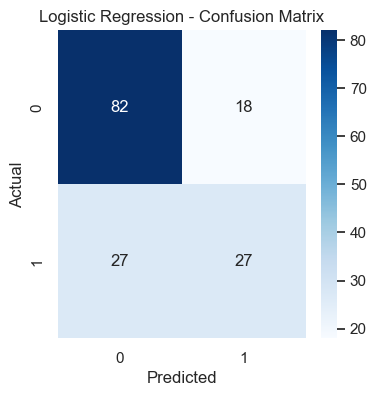

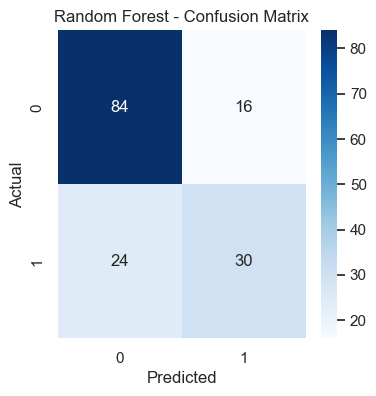

In [8]:
# Confusion matrix for both models
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

def plot_confusion(cm, title):
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

plot_confusion(cm_lr, "Logistic Regression - Confusion Matrix")
plot_confusion(cm_rf, "Random Forest - Confusion Matrix")

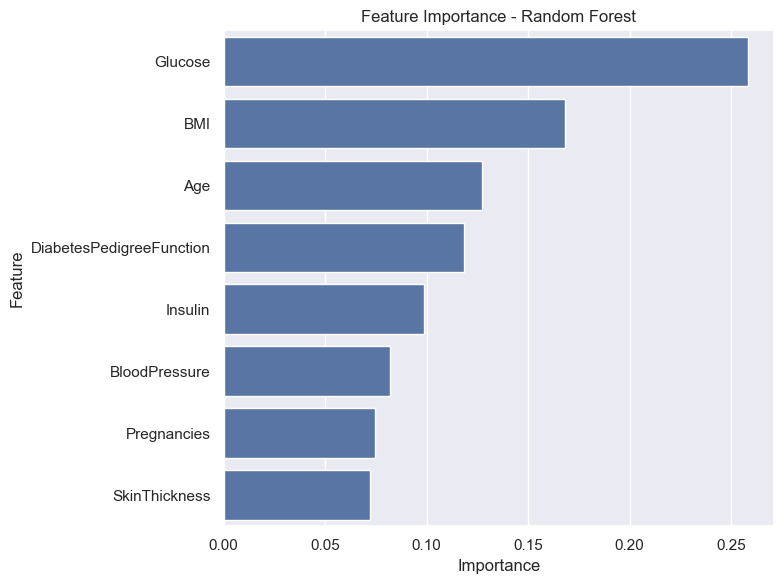

,Feature,Importance
1,Glucose,0.258275
5,BMI,0.168349
7,Age,0.127307
6,DiabetesPedigreeFunction,0.118427
4,Insulin,0.098892
2,BloodPressure,0.081850
0,Pregnancies,0.074549
3,SkinThickness,0.072352


In [9]:
# Feature importancr for random forest model
importances = rf.feature_importances_
feature_names = X.columns

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=feat_imp, x="Importance", y="Feature")
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.show()

feat_imp